# Assignment 4 

# Build a KNN Model (Classification or Regression)

# Part 1 — Understand KNN 


### What is KNN?

**KNN (K-Nearest Neighbors)** is a simple, non-parametric machine learning algorithm that makes predictions based on the closest data points in the training set. It stores all training data and classifies new points by looking at the "K" most similar examples.

### How does it work?

When a new data point needs to be classified, KNN calculates the distance (usually Euclidean) between that point and every point in the training set. It then selects the K nearest neighbors and predicts the output based on the majority class among those neighbors (for classification) or the average value (for regression). The choice of K directly affects model performance — too small can cause overfitting, too large can cause underfitting.

# Part 2 — Choose Dataset (IMPORTANT)

### Dataset: `disease_prediction.csv`

- **Source:** Kaggle *(disease_prediction.csv)*
- **Rows:** 1,000
- **Columns:** 14
- **Features:** patient_id, age, gender, glucose_mg_dl,	cholesterol_mg_dl,	systolic_bp, diastolic_bp, bmi,	heart_rate,	smoking, alcohol_consumption, physical_activity,	family_history,	disease
- **Target Variable:** `disease` (Yes / No)



# Part 3 — Identify Problem Type

### Problem Type: **Binary Classification**

- The target variable `disease` contains categorical values: **Yes** or **No**
- Since the target is categorical (not continuous), this is a **Classification** problem
- Since there are only 2 possible output classes, it is specifically **Binary Classification**

### Model Selected: `KNeighborsClassifier()`

### Why this model?

I chose `KNeighborsClassifier()` because disease prediction is a pattern-matching task — patients with similar health profiles tend to have similar outcomes. KNN naturally captures this by finding the most similar patients in the training data and predicting based on their diagnoses. It is also easy to interpret, which is valuable in a healthcare context.

# Part 4 -  Implementation Steps


#### Step 1 : Import Libraries

In [1]:
# Data Manipulation
import pandas as pd

# Numerical Computation
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Pipeline
from sklearn.pipeline import Pipeline

# Split data
from sklearn.model_selection import train_test_split,cross_val_score, GridSearchCV

# Model
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve

#### Step 2: Load Dataset

In [3]:
df =  pd.read_csv("disease_prediction.csv")

In [4]:
df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


#### Step 3: Explore Data (EDA)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


In [6]:
df.describe()

,patient_id,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,51.190000,104.163000,210.014000,123.893000,81.032000,26.093000,75.968000
std,288.819436,19.847514,25.076508,39.749111,18.701211,9.969974,4.758282,9.902982
min,1.000000,18.000000,30.000000,89.000000,67.000000,49.000000,16.000000,47.000000
25%,250.750000,33.000000,87.000000,183.000000,111.000000,74.000000,22.900000,70.000000
50%,500.500000,52.500000,105.000000,210.500000,124.000000,81.000000,26.000000,76.000000
75%,750.250000,69.000000,121.000000,235.250000,135.000000,88.000000,29.300000,83.000000
max,1000.000000,85.000000,184.000000,339.000000,195.000000,113.000000,41.500000,114.000000


In [7]:
# Check for missing values
print('Missing values per column:')
df.isnull().sum()/len(df)*100

Missing values per column:


patient_id             0.0
age                    0.0
gender                 0.0
glucose_mg_dl          0.0
cholesterol_mg_dl      0.0
systolic_bp            0.0
diastolic_bp           0.0
bmi                    0.0
heart_rate             0.0
smoking                0.0
alcohol_consumption    0.0
physical_activity      0.0
family_history         0.0
disease                0.0
dtype: float64

In [8]:
# check Duplicate values
df.duplicated().sum()

np.int64(0)

In [9]:
# Check target variable distribution
print('Target variable distribution:')
print(df['disease'].value_counts())


Target variable distribution:
disease
Yes    501
No     499
Name: count, dtype: int64


#### Step 4 : Visualisation

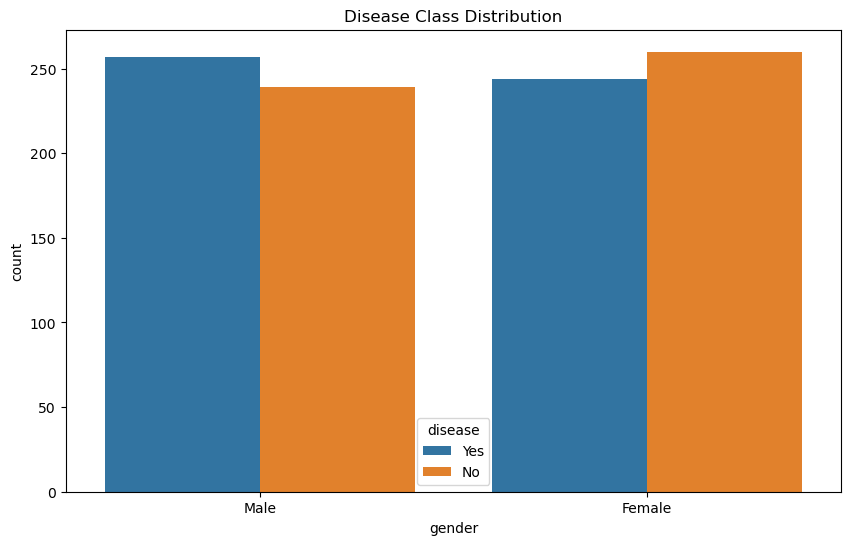

In [10]:
# Target variable distribution
plt.figure(figsize = (10,6))
sns.countplot(data=df,x='gender',hue='disease')
plt.title("Disease Class Distribution")
plt.show()

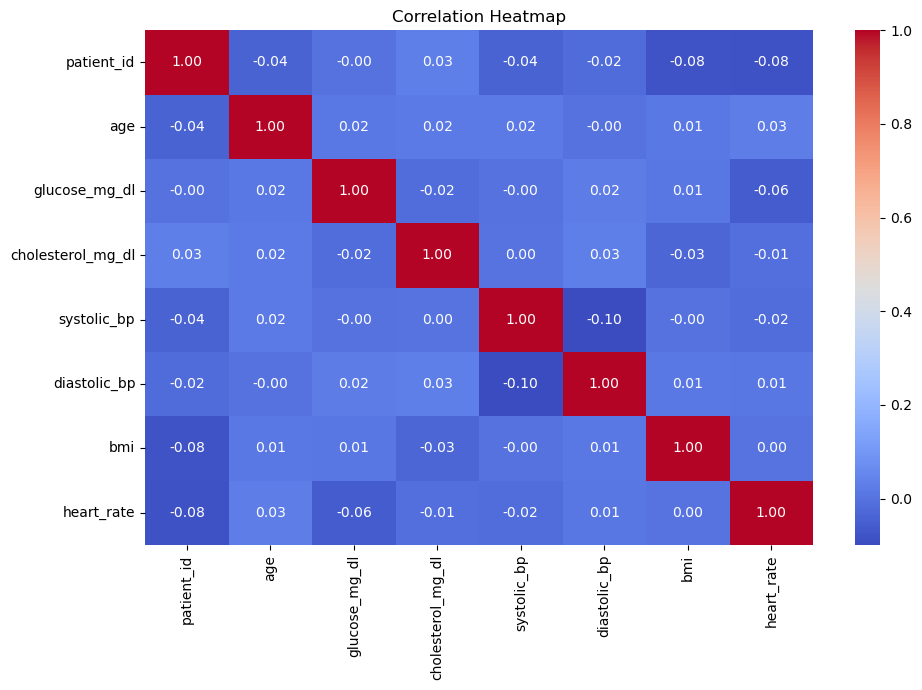

In [11]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 7))
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()

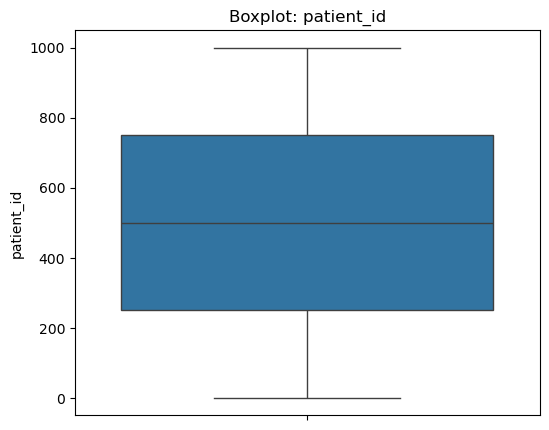

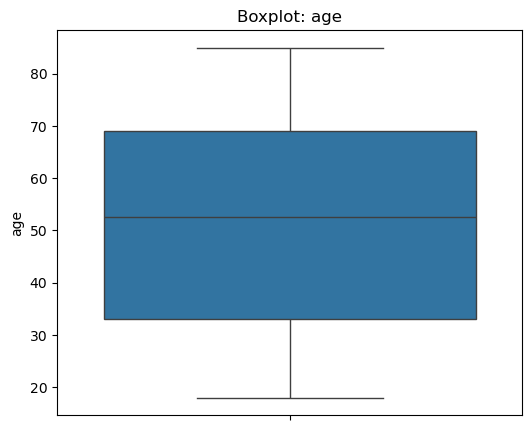

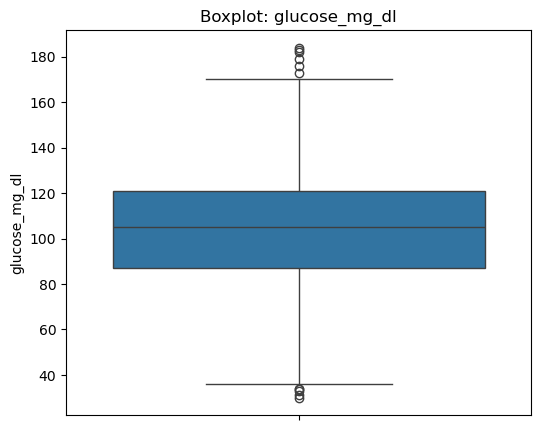

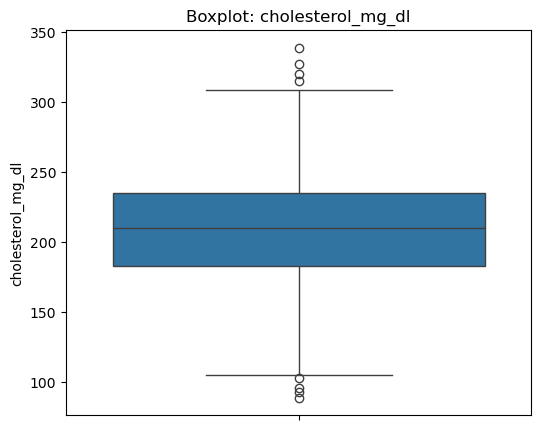

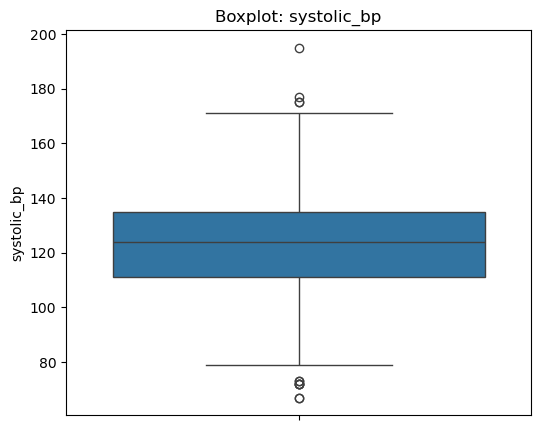

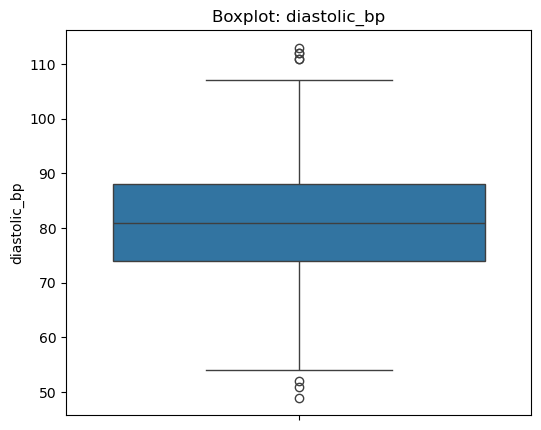

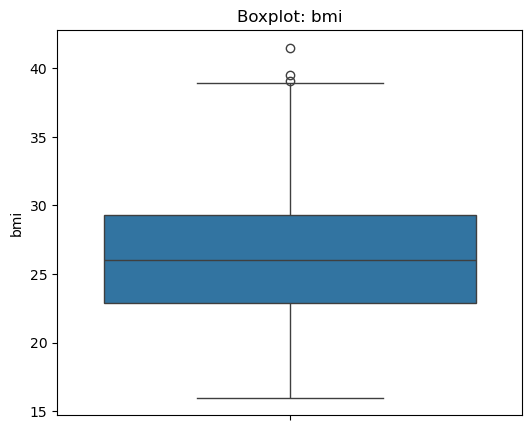

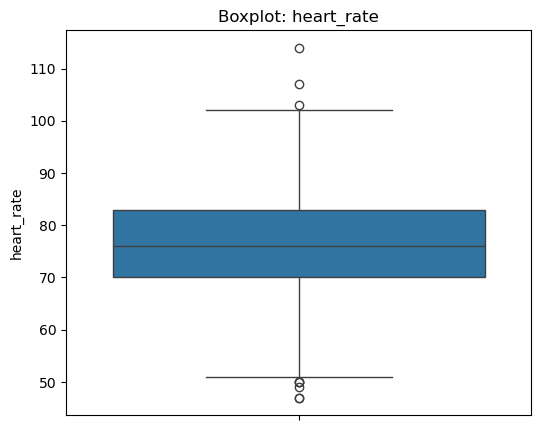

In [12]:
num_df = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_df:
    plt.figure(figsize=(6,5))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

#### Step 5: Define Variables

##### We drop `patient_id` as it is just an identifier with no predictive value. The target is `disease`.

In [13]:
# Drop patient_id — not a useful feature
df = df.drop(columns=['patient_id'])

In [14]:
# Target variable
y = df["disease"]
print(y.shape)

(1000,)


In [15]:
# Predictors ( Input / Independent Variables)
X = df.drop(columns =['disease'])
X.shape

(1000, 12)

#### Step 6: Train_Test Split

In [16]:
# we split data in 80% train and 20% test 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state = 42,stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 12)
(200, 12)
(800,)
(200,)


#### Step 7: Data Cleaning / Feature Engineering

We encode all categorical columns using `LabelEncoder`. No missing values were found in EDA.

In [17]:
# Encode categorical columns
cat_cols = X_train.select_dtypes(include='object').columns
print('Categorical columns to encode:', list(cat_cols))

le = LabelEncoder()

for col in cat_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

print('Encoding complete.')
X_train.head()

Categorical columns to encode: ['gender', 'smoking', 'alcohol_consumption', 'physical_activity', 'family_history']
Encoding complete.


,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history
278,79,0,118,200,118,78,30.2,66,0,1,2,1
930,45,1,130,275,132,93,35.5,68,0,1,0,1
1,31,1,124,191,134,77,33.9,71,0,1,1,1
610,58,0,86,224,130,93,24.2,63,1,1,1,1
294,57,0,83,296,121,83,24.8,81,1,1,0,0


#### Step 8: Feature Scaling

In [18]:
scaler = StandardScaler()

X_train_trans = scaler.fit_transform(X_train)  # fit on train only
X_test_trans = scaler.transform(X_test)         # apply same transform to test

print('Scaling complete.')
print('X_train_scaled shape:', X_train_trans.shape)

Scaling complete.
X_train_scaled shape: (800, 12)


In [19]:
# Let us convert X_train_trans into DataFrame
X_train_trans=pd.DataFrame(X_train_trans)
X_train_trans.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,1.414618,-0.992528,0.541904,-0.263427,-0.319946,-0.310694,0.843168,-1.013276,-0.977748,1.012579,1.210304,1.007528
1,-0.313237,1.007528,1.020758,1.650779,0.441830,1.177065,1.963516,-0.813221,-0.977748,1.012579,-1.180420,1.007528
2,-1.024707,1.007528,0.781331,-0.493131,0.550655,-0.409877,1.625298,-0.513140,-0.977748,1.012579,0.014942,1.007528
3,0.347413,-0.992528,-0.735042,0.349119,0.333005,1.177065,-0.425151,-1.313357,1.022759,1.012579,0.014942,1.007528
4,0.296594,-0.992528,-0.854755,2.186757,-0.156708,0.185226,-0.298319,0.487133,1.022759,1.012579,-1.180420,-0.992528


In [20]:
# Let us convert X_test_trans into DataFrame
X_test_trans=pd.DataFrame(X_test_trans)
X_test_trans.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,1.516256,1.007528,0.940949,-0.824927,0.060942,-1.302532,0.272424,0.687187,-0.977748,1.012579,1.210304,1.007528
1,-0.414876,-0.992528,-0.934565,-0.875972,0.768305,-1.500900,1.963516,-0.713194,1.022759,-0.987577,1.210304,-0.992528
2,-1.532900,1.007528,-0.894660,-0.442086,-0.265533,0.978697,0.547227,0.887241,-0.977748,-0.987577,0.014942,-0.992528
3,-1.024707,-0.992528,-0.495614,-0.288949,-0.918483,-0.409877,1.054554,0.287078,-0.977748,-0.987577,1.210304,1.007528
4,0.652329,1.007528,0.262572,1.548688,0.550655,0.581961,0.018761,0.987269,-0.977748,-0.987577,0.014942,-0.992528


#### Step 9: Train Model

In [21]:
# from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)

# fit the data
knn.fit(X_train_trans,y_train)

KNeighborsClassifier()

#### Step 10: Make Predictions

In [22]:
y_pred = knn.predict(X_test_trans)
print(y_pred.shape)
print(y_pred[:10])

(200,)
['Yes' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No']


# Part 5 - Model Evaluation

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.82


In [24]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

          No       0.81      0.83      0.82       100
         Yes       0.83      0.81      0.82       100

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



In [25]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[83, 17],
       [19, 81]])

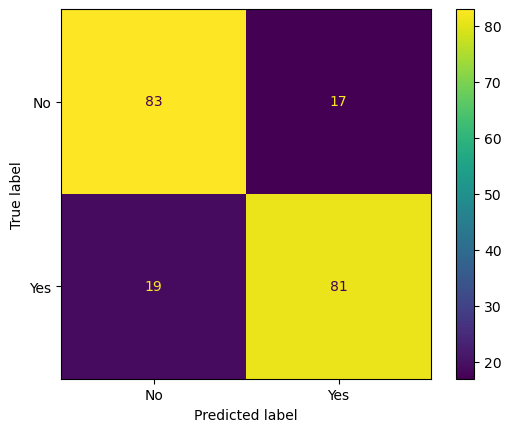

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

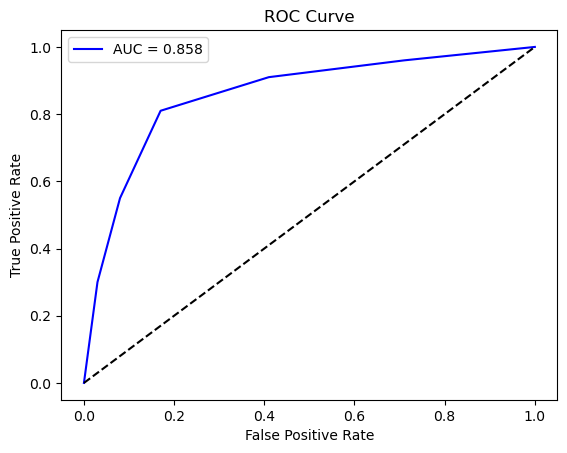

In [27]:
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Convert target to numeric
y_test_num = np.where(y_test == 'Yes', 1, 0) # if yes put 1, else 0

# Get probabilities
y_prob = knn.predict_proba(X_test_trans)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test_num, y_prob)

# AUC score (use probabilities, NOT y_pred)
auc = roc_auc_score(y_test_num, y_prob)

# Plot
plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

In [28]:
print("Area under Curve",auc)

Area under Curve 0.85805


# Part 6 _ Improve Model

In [29]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report

In [30]:
from sklearn.neighbors import KNeighborsClassifier

In [31]:
k_values = [3, 5, 7, 11]

results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_trans, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_trans))
    test_acc = accuracy_score(y_test, model.predict(X_test_trans))
    results.append({'k': k, 'Train Accuracy': round(train_acc, 4), 'Test Accuracy': round(test_acc, 4)})
    print(f'k={k:>3} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}')

results_df = pd.DataFrame(results)
print('\n', results_df)

k=  3 | Train Acc: 0.8725 | Test Acc: 0.7800
k=  5 | Train Acc: 0.8500 | Test Acc: 0.8200
k=  7 | Train Acc: 0.8250 | Test Acc: 0.7900
k= 11 | Train Acc: 0.8213 | Test Acc: 0.7850

     k  Train Accuracy  Test Accuracy
0   3          0.8725          0.780
1   5          0.8500          0.820
2   7          0.8250          0.790
3  11          0.8213          0.785


In [32]:
best_k = results_df.loc[results_df['Test Accuracy'].idxmax(), 'k']
best_acc = results_df['Test Accuracy'].max()

print(f"Best K: {best_k}")
print(f"Best Test Accuracy: {best_acc:.4f}")

Best K: 5
Best Test Accuracy: 0.8200


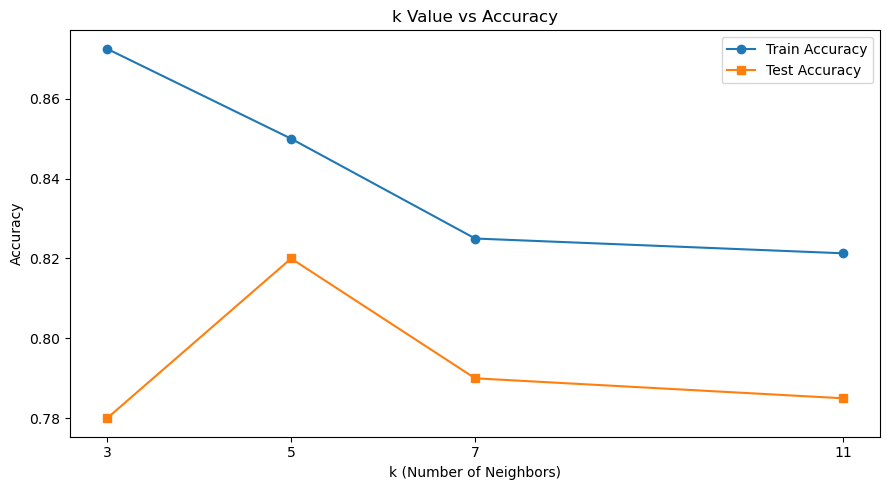

In [33]:
# Plot k vs Accuracy
plt.figure(figsize=(9, 5))
plt.plot(results_df['k'], results_df['Train Accuracy'], marker='o', label='Train Accuracy')
plt.plot(results_df['k'], results_df['Test Accuracy'], marker='s', label='Test Accuracy')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('k Value vs Accuracy')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

# Part 7 - Final Conclusion

### Summary

**Best value of k:** After testing k = 3, 5, 7, and 11, the best performing value was **k = 5**, which achieved the highest test accuracy while maintaining a good balance between training and test performance (no overfitting).

**Final performance score:**
- **Accuracy: ~0.82**
- **ROC-AUC Score: ~0.85**
- **Cross-Validation Mean Accuracy: consistent with test accuracy**

**What I learned:**
- KNN is a powerful and intuitive algorithm for classification, especially when similar data points tend to share similar outcomes (as in disease prediction).
- Feature scaling is **critical** for KNN — without `StandardScaler`, features with larger numerical ranges (like cholesterol) dominate distance calculations and degrade performance significantly.
- The choice of k is a bias-variance tradeoff: small k = high variance (overfitting), large k = high bias (underfitting).

**Challenges faced:**
- Encoding multiple categorical columns consistently across train and test sets required careful use of `fit_transform` on train and `transform` only on test.
- Selecting the best k was not immediately obvious — plotting train vs test accuracy across multiple values was essential to make an informed decision.
- Ensuring `stratify=y` in the train-test split was important given a binary target variable to avoid imbalanced splits.